# **Lab 6 Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers**


# Download and load the Breast Cancer Wisconsin (Diagnostic) dataset

In [ ]:
import pandas as pd

columns = [
    'ID','Diagnosis',
    'Radius_Mean','Texture_Mean','Perimeter_Mean','Area_Mean','Smoothness_Mean',
    'Compactness_Mean','Concavity_Mean','Concave_Points_Mean','Symmetry_Mean','Fractal_Dimension_Mean',
    'Radius_SE','Texture_SE','Perimeter_SE','Area_SE','Smoothness_SE',
    'Compactness_SE','Concavity_SE','Concave_Points_SE','Symmetry_SE','Fractal_Dimension_SE',
    'Radius_Worst','Texture_Worst','Perimeter_Worst','Area_Worst','Smoothness_Worst',
    'Compactness_Worst','Concavity_Worst','Concave_Points_Worst','Symmetry_Worst','Fractal_Dimension_Worst'
]
data = pd.read_csv("wdbc.data", header=None, names=columns)
data.head()

,ID,Diagnosis,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Perform exploratory data analysis and data preprocessing

In [ ]:
data.shape

(569, 32)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   Radius_Mean              569 non-null    float64
 3   Texture_Mean             569 non-null    float64
 4   Perimeter_Mean           569 non-null    float64
 5   Area_Mean                569 non-null    float64
 6   Smoothness_Mean          569 non-null    float64
 7   Compactness_Mean         569 non-null    float64
 8   Concavity_Mean           569 non-null    float64
 9   Concave_Points_Mean      569 non-null    float64
 10  Symmetry_Mean            569 non-null    float64
 11  Fractal_Dimension_Mean   569 non-null    float64
 12  Radius_SE                569 non-null    float64
 13  Texture_SE               569 non-null    float64
 14  Perimeter_SE             5

In [ ]:
data.describe()

,ID,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Check for missing values and prepare the dataset for classification

In [ ]:
print(data.isnull().sum())

ID                         0
Diagnosis                  0
Radius_Mean                0
Texture_Mean               0
Perimeter_Mean             0
Area_Mean                  0
Smoothness_Mean            0
Compactness_Mean           0
Concavity_Mean             0
Concave_Points_Mean        0
Symmetry_Mean              0
Fractal_Dimension_Mean     0
Radius_SE                  0
Texture_SE                 0
Perimeter_SE               0
Area_SE                    0
Smoothness_SE              0
Compactness_SE             0
Concavity_SE               0
Concave_Points_SE          0
Symmetry_SE                0
Fractal_Dimension_SE       0
Radius_Worst               0
Texture_Worst              0
Perimeter_Worst            0
Area_Worst                 0
Smoothness_Worst           0
Compactness_Worst          0
Concavity_Worst            0
Concave_Points_Worst       0
Symmetry_Worst             0
Fractal_Dimension_Worst    0
dtype: int64


In [ ]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [ ]:
data = data.drop("ID", axis=1)

data["Diagnosis"] = data["Diagnosis"].map({
    "M":1,
    "B":0
})

In [ ]:
X = data.drop("Diagnosis", axis=1)

y = data["Diagnosis"]

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Split the dataset into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

print("Training Samples:",X_train.shape[0])
print("Testing Samples:",X_test.shape[0])

Training Samples: 398
Testing Samples: 171


# Train a Logistic Regression classifier

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

# Train a K Nearest Neighbors (KNN) classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

y_pred_knn = knn.predict(X_test)

# Evaluate both classifiers using

Accuracy

Precision

Recall

F1 Score

Confusion Matrix


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

print("Logistic Regression")

print("Accuracy :",accuracy_score(y_test,y_pred_lr))

print("Precision :",precision_score(y_test,y_pred_lr))

print("Recall :",recall_score(y_test,y_pred_lr))

print("F1 Score :",f1_score(y_test,y_pred_lr))

print("Confusion Matrix")

print(confusion_matrix(y_test,y_pred_lr))

Logistic Regression
Accuracy : 0.9824561403508771
Precision : 0.96875
Recall : 0.9841269841269841
F1 Score : 0.9763779527559056
Confusion Matrix
[[106   2]
 [  1  62]]


In [ ]:
print("KNN")

print("Accuracy :",accuracy_score(y_test,y_pred_knn))

print("Precision :",precision_score(y_test,y_pred_knn))

print("Recall :",recall_score(y_test,y_pred_knn))

print("F1 Score :",f1_score(y_test,y_pred_knn))

print("Confusion Matrix")

print(confusion_matrix(y_test,y_pred_knn))

KNN
Accuracy : 0.9590643274853801
Precision : 0.9516129032258065
Recall : 0.9365079365079365
F1 Score : 0.944
Confusion Matrix
[[105   3]
 [  4  59]]


# Compare the performance of the two classifiers using a comparison table

In [ ]:
comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Logistic Regression":[

        accuracy_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_lr)
    ],
    "KNN":[

        accuracy_score(y_test,y_pred_knn),
        precision_score(y_test,y_pred_knn),
        recall_score(y_test,y_pred_knn),
        f1_score(y_test,y_pred_knn)
    ]
})
comparison

,Metric,Logistic Regression,KNN
0,Accuracy,0.982456,0.959064
1,Precision,0.968750,0.951613
2,Recall,0.984127,0.936508
3,F1 Score,0.976378,0.944000


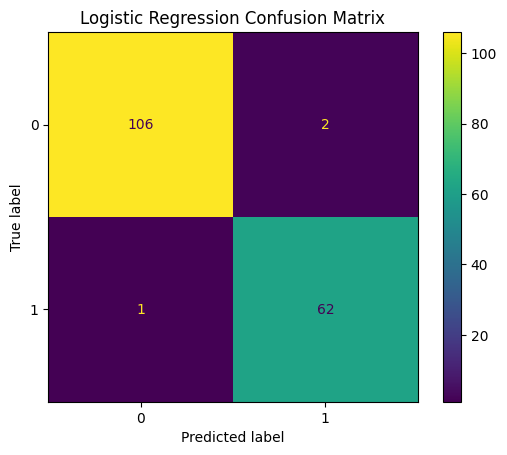

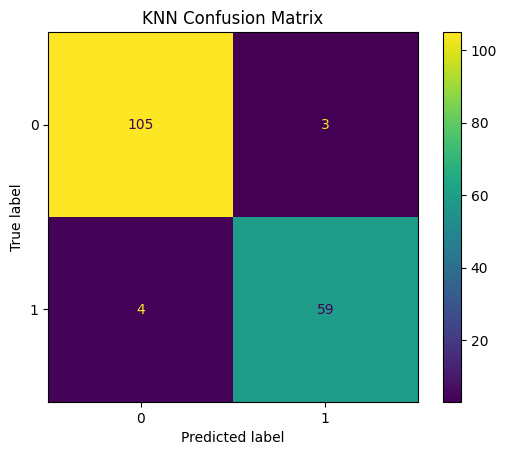

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN Confusion Matrix")
plt.show()

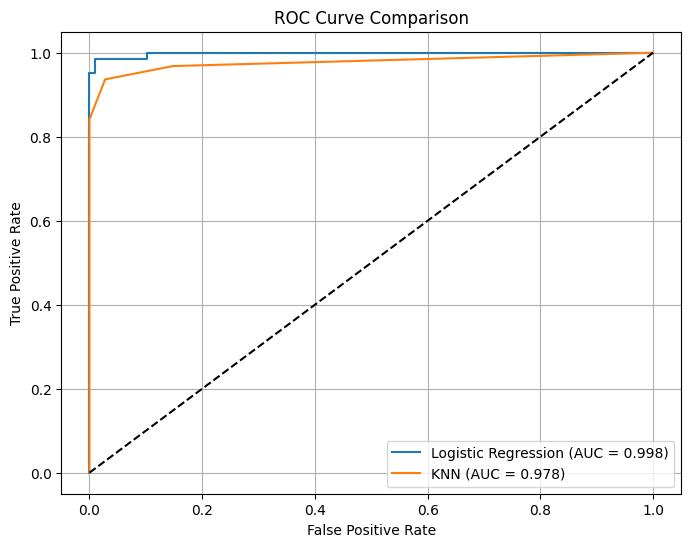

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


lr_probs = lr.predict_proba(X_test)[:, 1]
knn_probs = knn.predict_proba(X_test)[:, 1]


fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)

auc_lr = auc(fpr_lr, tpr_lr)
auc_knn = auc(fpr_knn, tpr_knn)


plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

plt.plot(fpr_knn, tpr_knn,
         label=f'KNN (AUC = {auc_knn:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

# Interpret the results and comment on the better-performing classifier for the given dataset



Logistic Regression made only 3 incorrect predictions while KNN made 7 it also had fewer false positives and false negatives

ROC curve of Logistic Regression lies closer to the top-left corner and has a higher AUC indicates that Logistic Regression has better class discrimination and overall classification performance than KNN